In [1]:
import pandas as pd
import numpy as np


In [11]:
df_in     = pd.read_csv("player_transfer.csv")
df_league = pd.read_csv("league_table.csv")

print(df_in.shape, df_league.shape)

(12305, 8) (644, 10)


In [12]:
df_in["Fee_clean"] = df_in["Fee"].str.replace("€", "").str.replace("m", "")
df_in["Fee_clean"] = pd.to_numeric(df_in["Fee_clean"], errors="coerce")

df_in_perm = df_in[df_in["Fee_clean"].notna()]

In [13]:
df_in_perm.sort_values("Fee_clean", ascending=False)[
    ["Player Name", "Team", "Year", "Fee_clean"]
].head(10)

,Player Name,Team,Year,Fee_clean
2663,Enzo Fernández,Chelsea FC,2022,121.0
6087,Jack Grealish,Manchester City,2021,117.5
139,Declan Rice,Arsenal FC,2023,116.6
2634,Moisés Caicedo,Chelsea FC,2023,116.0
2691,Romelu Lukaku,Chelsea FC,2021,113.0
6723,Paul Pogba,Manchester United,2016,105.0
6631,Antony,Manchester United,2022,95.0
6039,Josko Gvardiol,Manchester City,2023,90.0
6688,Harry Maguire,Manchester United,2019,87.0
6655,Jadon Sancho,Manchester United,2021,85.0


<Axes: xlabel='Team'>

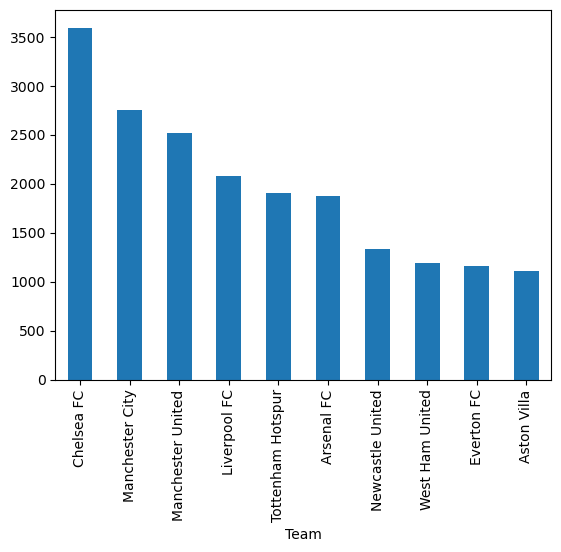

In [14]:
club_spending = df_in_perm.groupby("Team")["Fee_clean"].sum().sort_values(ascending=False)

club_spending.head(10)
club_spending.head(10).plot(kind="bar")

<Axes: xlabel='Total_Spending', ylabel='Pts'>

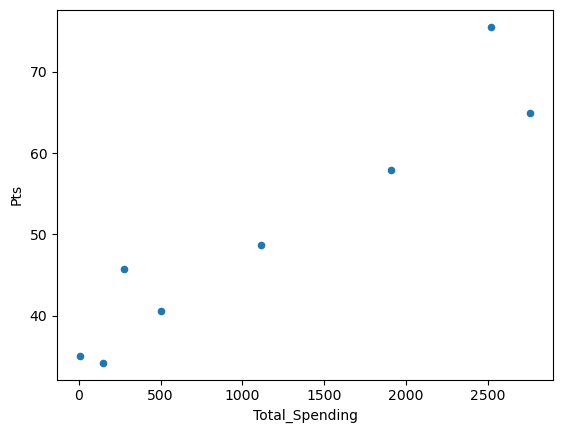

In [15]:
spending_df = club_spending.reset_index()
spending_df.columns = ["Team", "Total_Spending"]

spending_df["Team"] = spending_df["Team"].replace({
    "Manchester United": "Man Utd",
    "Manchester City": "Man City",
    "Tottenham Hotspur": "Tottenham"
})

league_avg = df_league.groupby("Club")["Pts"].mean().reset_index()

merged_df = pd.merge(
    spending_df,
    league_avg,
    left_on="Team",
    right_on="Club",
    how="inner"
)

merged_df.plot(x="Total_Spending", y="Pts", kind="scatter")

In [16]:
merged_df["Efficiency"] = merged_df["Pts"] / merged_df["Total_Spending"]

filtered_df = merged_df[merged_df["Total_Spending"] > 500]

filtered_df.sort_values("Efficiency")
filtered_df.sort_values("Efficiency", ascending=False)

,Team,Total_Spending,Club,Pts,Efficiency
4,Crystal Palace,500.08,Crystal Palace,40.600000,0.081187
3,Aston Villa,1113.93,Aston Villa,48.724138,0.043741
2,Tottenham,1907.53,Tottenham,57.937500,0.030373
1,Man Utd,2521.06,Man Utd,75.531250,0.029960
0,Man City,2759.18,Man City,64.888889,0.023517


In [17]:
df_in_perm.groupby("Position Name")["Fee_clean"].sum().sort_values(ascending=False)


Position Name
Forward       11056.38
Midfielder     9125.25
Defender       7602.54
Goalkeeper     1269.28
Name: Fee_clean, dtype: float64


df_in_perm.plot(x="Age", y="Fee_clean", kind="scatter")

This analysis explored the relationship between transfer spending and team performance in the Premier League.

The results show that higher spending is generally associated with better performance, as top clubs consistently invest heavily in player transfers. However, the relationship is not strictly linear — increased spending does not always guarantee improved results.

Efficiency analysis revealed significant differences between clubs. Some teams achieve strong performance with relatively lower spending, while others underperform despite large investments. This highlights the importance of strategic decision-making in player recruitment.

Additional insights indicate that transfer investments are concentrated in specific positions and age groups, suggesting that clubs prioritize both immediate impact and long-term value.

Overall, while financial investment plays a crucial role in success, effective utilization of resources and smart transfer strategies are equally important in determining team performance.